In [1]:
! !pip install nltk worldcloud

/bin/bash: line 1: !pip: command not found


In [2]:
import re
import string
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from plotly import graph_objs as go
import plotly.express as px
import plotly.figure_factory as ff
from collections import Counter
import nltk
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from PIL import Image
nltk.download('stopwords') ##Downloading stopword corpus

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from tqdm import tqdm
import os
import spacy
import random
from spacy.util import compounding
from spacy.util import minibatch
from collections import defaultdict
from collections import Counter
# import keras
# from keras.models import Sequential
# from keras.initializers import Constant
# from keras.layers import (LSTM,
#                           Embedding,
#                           BatchNormalization,
#                           Dense,
#                           TimeDistributed,
#                           Dropout,
#                           Bidirectional,
#                           Flatten,
#                           GlobalMaxPool1D)
# from keras.preprocessing.text import Tokenizer
# from keras.preprocessing.sequence import pad_sequences
# from keras.layers.embeddings import Embedding
# from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
# from keras.optimizers import Adam

# from sklearn.metrics import (
#     precision_score,
#     recall_score,
#     f1_score,
#     classification_report,
#     accuracy_score
# )

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [9]:
df = pd.read_csv('spam.csv', encoding = "latin-1")

df = df.dropna(how="any", axis = 1)
df.columns = ['target', 'message']
df.head()

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
# The 'spam.csv' file was loaded successfully by a later cell (`-uWHsqKlX9mJ`).
# Commenting out this redundant data loading to prevent future errors.
# df = pd.read_csv('spam.csv', encoding = "latin-1")
# df = df.dropna(how="any", axis = 1)
# df.columns = ['target', 'message']
# df.head()

In [10]:
df['message_len'] = df['message'].apply(lambda x: len(x.split(' ')))
df.head()

,target,message,message_len
0,ham,"Go until jurong point, crazy.. Available only ...",20
1,ham,Ok lar... Joking wif u oni...,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28
3,ham,U dun say so early hor... U c already then say...,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",13


In [11]:
max(df['message_len'])


171

In [12]:
min(df['message_len'])

1

In [13]:
balance_counts = df.groupby('target')['target'].agg('count').values
print(balance_counts)

[4825  747]


In [14]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=['ham'],
    y=[balance_counts[0]],
    name='ham',
    text=[balance_counts[0]],
    textposition='auto',
    marker_color='indianred'
))
fig.add_trace(go.Bar(
    x=['spam'],
    y=[balance_counts[1]],
    name='spam',
    text=[balance_counts[1]],
    textposition='auto',
    marker_color='lightsalmon'

))

fig.update_layout(barmode='stack', xaxis={'categoryorder':'total descending'})
fig.show()
#

In [15]:
ham_df = df[df['target'] == 'ham']['message_len'].value_counts().sort_index()
spam_df = df[df['target'] == 'spam']['message_len'].value_counts().sort_index()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=ham_df.index,
    y=ham_df.values,
    name='ham',
    fill='tozeroy',
    mode='lines+markers'
))

fig.add_trace(go.Scatter(
    x=spam_df.index,
    y=spam_df.values,
    name='spam',
    fill='tozeroy',
    mode='lines+markers'
))

fig.update_layout(
    xaxis_title='Message Length',
    yaxis_title='Count'
)

fig.update_xaxes(range=[0,70])

fig.show()


In [16]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

df['message_clean'] = df['message'].apply(clean_text)
df.head()

<>:3: SyntaxWarning:

invalid escape sequence '\['

<>:4: SyntaxWarning:

invalid escape sequence '\S'

<>:8: SyntaxWarning:

invalid escape sequence '\w'

<>:3: SyntaxWarning:

invalid escape sequence '\['

<>:4: SyntaxWarning:

invalid escape sequence '\S'

<>:8: SyntaxWarning:

invalid escape sequence '\w'

/tmp/ipykernel_1841/3263597791.py:3: SyntaxWarning:

invalid escape sequence '\['

/tmp/ipykernel_1841/3263597791.py:4: SyntaxWarning:

invalid escape sequence '\S'

/tmp/ipykernel_1841/3263597791.py:8: SyntaxWarning:

invalid escape sequence '\w'



,target,message,message_len,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",20,go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,6,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entry in a wkly comp to win fa cup final...
3,ham,U dun say so early hor... U c already then say...,11,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,nah i dont think he goes to usf he lives aroun...


In [17]:
stop_words= stopwords.words('english')
more_stopwords = ['u', 'im', 'c']
stop_words = stop_words + more_stopwords

def remove_stopwords(text):
    text = ' '.join(word for word in text.split(' ') if word not in stop_words)
    return text

df['message_clean'] = df['message_clean'].apply(remove_stopwords)
df.head()

,target,message,message_len,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",20,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,6,ok lar joking wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entry wkly comp win fa cup final tkts m...
3,ham,U dun say so early hor... U c already then say...,11,dun say early hor already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,nah dont think goes usf lives around though


In [18]:
stemmer = nltk.SnowballStemmer("english")
def stem_words(text):
    return " ".join([stemmer.stem(word) for word in text.split()])

df['message_clean'] = df['message_clean'].apply(stem_words)

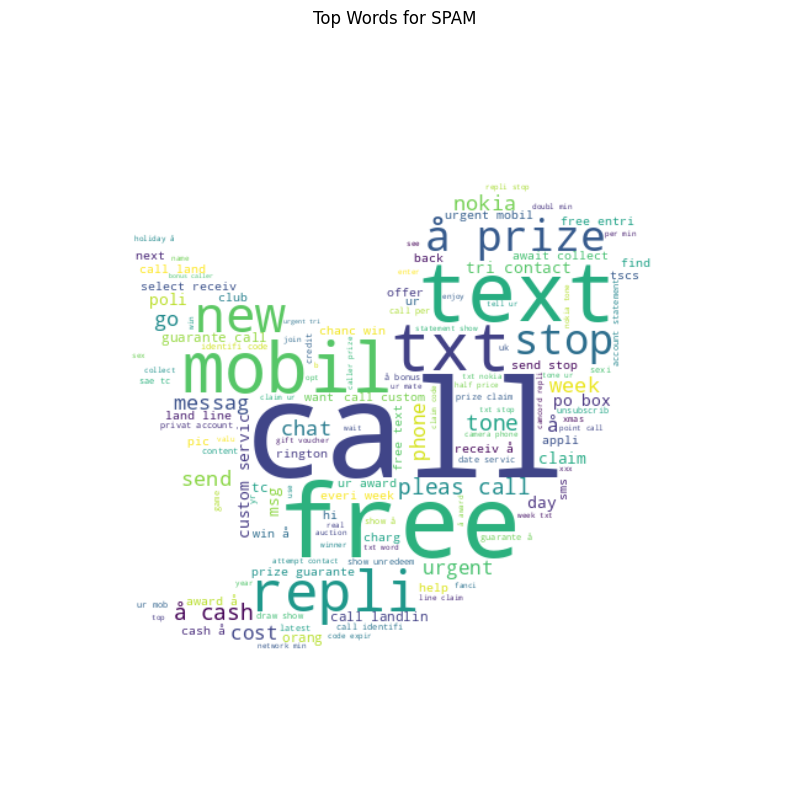

In [21]:
twitter_mask = np.array(Image.open("twitter_mask4.jpg.jpeg"))

wc = WordCloud(
    background_color="white",
    max_words=200,
    mask=twitter_mask
)

wc.generate(' '.join(text for text in df.loc[df['target'] == 'spam', 'message_clean']))
plt.figure(figsize=(18,10))
plt.title('Top Words for SPAM')
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [24]:
import pandas as pd

df = pd.read_csv('spam.csv', encoding='latin-1')

df = df.dropna(how='any', axis=1)
df.columns = ['target', 'message']

df.head()

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [25]:
df.shape

(5572, 2)

In [26]:
from sklearn.model_selection import train_test_split

X = df['message']
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer()

x_train_dtm = vect.fit_transform(x_train)
x_test_dtm = vect.transform(x_test)

In [28]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf_transformer = TfidfTransformer()

x_train_tfidf = tfidf_transformer.fit_transform(x_train_dtm)
x_test_tfidf = tfidf_transformer.transform(x_test_dtm)

Accuracy: 0.9623
Precision: 1.0000
Recall: 0.7200
F1 Score: 0.8372

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115


Confusion Matrix:


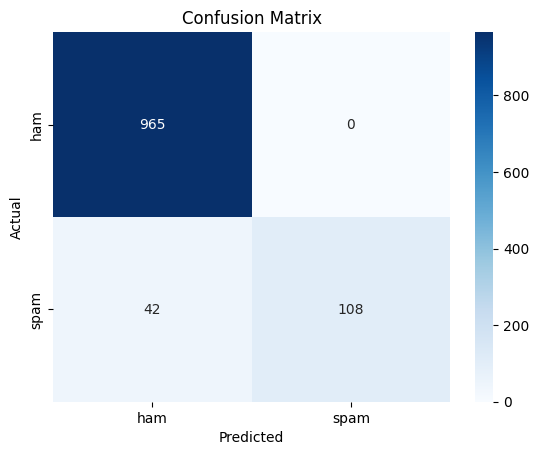

In [29]:
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

# Train a Multinomial Naive Bayes model
mnb = MultinomialNB()
mnb.fit(x_train_tfidf, y_train)

# Make predictions on the test set
y_pred = mnb.predict(x_test_tfidf)

# Evaluate the model
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred, pos_label='spam')
recall = metrics.recall_score(y_test, y_pred, pos_label='spam')
f1_score = metrics.f1_score(y_test, y_pred, pos_label='spam')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")

# Display classification report and confusion matrix
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

The model's performance metrics (accuracy, precision, recall, F1-score) provide insights into how well it distinguishes between 'ham' and 'spam' messages. The confusion matrix visually represents the correct and incorrect predictions.

Now, let's use the trained Multinomial Naive Bayes model to predict whether a new message is 'spam' or 'ham'.

In [30]:
import re
import string
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

from sklearn.feature_extraction.text import CountVectorizer # Added for clarity
from sklearn.feature_extraction.text import TfidfTransformer # Added for clarity
from sklearn.naive_bayes import MultinomialNB # Added for clarity, mnb also used

def clean_text(text):
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

stop_words = stopwords.words('english')
more_stopwords = ['u', 'im', 'c']
stop_words = stop_words + more_stopwords

def remove_stopwords(text):
    text = ' '.join(word for word in text.split(' ') if word not in stop_words)
    return text

stemmer = nltk.SnowballStemmer("english")
def stem_words(text):
    return " ".join([stemmer.stem(word) for word in text.split()])

def predict_message(message):
    # Clean the message
    cleaned_message = clean_text(message)
    cleaned_message = remove_stopwords(cleaned_message)
    cleaned_message = stem_words(cleaned_message)

    # Transform the message using the fitted CountVectorizer and TfidfTransformer
    # These objects (vect, tfidf_transformer, mnb) are expected to be defined
    # in the global scope from previous executed cells.
    try:
        message_dtm = vect.transform([cleaned_message])
        message_tfidf = tfidf_transformer.transform(message_dtm)

        # Make prediction
        prediction = mnb.predict(message_tfidf)

        return prediction[0]
    except NameError as e:
        return f"Error: {e}. One or more of 'vect', 'tfidf_transformer', or 'mnb' are not defined. Please ensure all preceding cells that define these objects have been run."

# Test with a new message
new_message_spam = "WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! Call 09061701461. Claim code KL60N. Valid 12hrs only."
new_message_ham = "Hi, hope you are doing well. Just checking in."

print(f"'{{new_message_spam}}' is predicted as: {predict_message(new_message_spam)}")
print(f"'{{new_message_ham}}' is predicted as: {predict_message(new_message_ham)}")

'{new_message_spam}' is predicted as: spam
'{new_message_ham}' is predicted as: ham


<>:13: SyntaxWarning:

invalid escape sequence '\['

<>:14: SyntaxWarning:

invalid escape sequence '\S'

<>:18: SyntaxWarning:

invalid escape sequence '\w'

<>:13: SyntaxWarning:

invalid escape sequence '\['

<>:14: SyntaxWarning:

invalid escape sequence '\S'

<>:18: SyntaxWarning:

invalid escape sequence '\w'

/tmp/ipykernel_1841/1887815405.py:13: SyntaxWarning:

invalid escape sequence '\['

/tmp/ipykernel_1841/1887815405.py:14: SyntaxWarning:

invalid escape sequence '\S'

/tmp/ipykernel_1841/1887815405.py:18: SyntaxWarning:

invalid escape sequence '\w'

